In [1]:
import sqlite3
import pandas as pd
import plotly.express as px
from PIL import Image
import matplotlib.pyplot as plt


In [ ]:
# --- Load coordinates from SpatiaLite ---
conn = sqlite3.connect("coords_embeddings.db")
df  = pd.read_sql("SELECT id, x, y,emb FROM patches", conn)


In [3]:
import numpy as np
df["x"] = np.random.rand(len(df))
df["y"] = np.random.rand(len(df))


In [4]:
df["x"]

0       0.853665
1       0.188374
2       0.096499
3       0.792135
4       0.149485
          ...   
6266    0.768637
6267    0.228401
6268    0.075719
6269    0.702936
6270    0.524309
Name: x, Length: 6271, dtype: float64

In [5]:
import plotly.graph_objs as go

fw = go.FigureWidget(data=go.Scatter(
    x=df["x"], y=df["y"],
    mode="markers",
    customdata=df["id"],
))
fw.layout.dragmode = "lasso"

selected_ids = []

def on_select(trace, points, selector):
    selected_ids.clear()
    selected_ids.extend([trace.customdata[i] for i in points.point_inds])
    print(f"Selected {len(selected_ids)} points")

fw.data[0].on_selection(on_select)
fw

FigureWidget({
    'data': [{'customdata': array([   0,    1,    2, ..., 6268, 6269, 6270], shape=(6271,)),
              'mode': 'markers',
              'type': 'scatter',
              'uid': '51080b1f-cd7e-4781-8fb4-bd48667ec527',
              'x': array([0.85366519, 0.18837417, 0.09649852, ..., 0.07571945, 0.70293637,
                          0.52430944], shape=(6271,)),
              'y': array([0.73274403, 0.8985304 , 0.63688655, ..., 0.07910076, 0.49464863,
                          0.84884729], shape=(6271,))}],
    'layout': {'dragmode': 'lasso', 'template': '...'}
})

In [41]:
len(selected_ids)

73

Selected 73 points


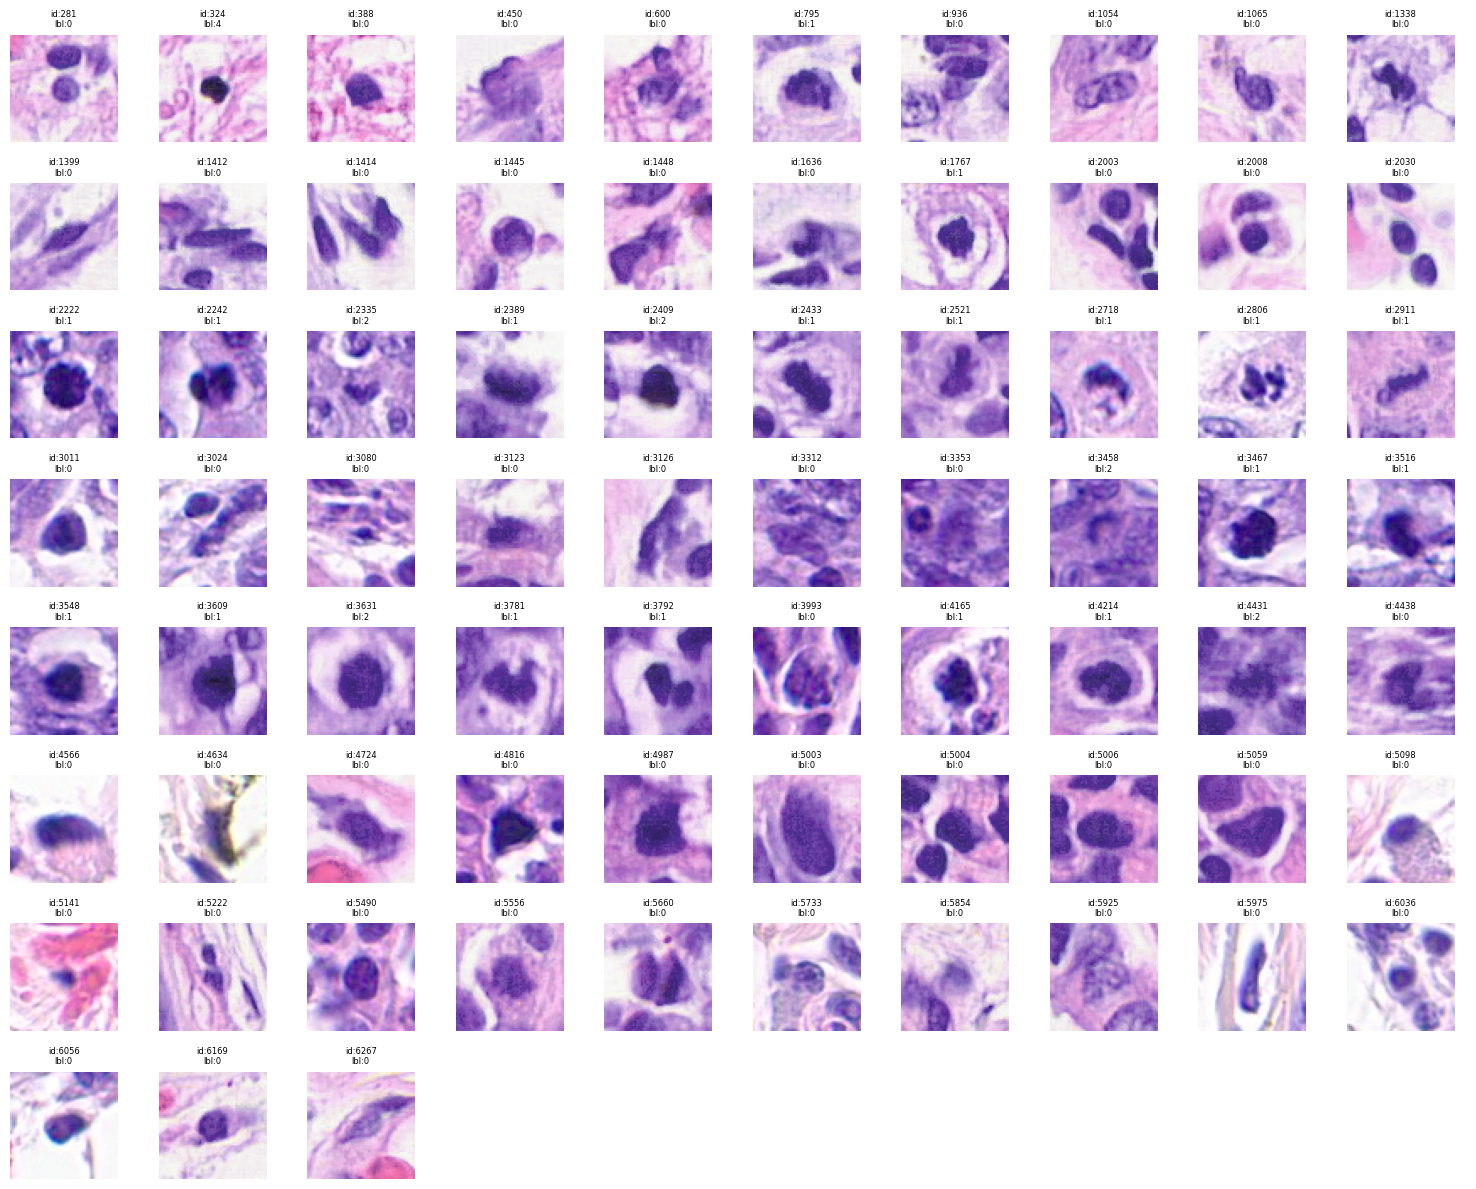

In [40]:
import numpy as np
import matplotlib.pyplot as plt

print(f"Selected {len(selected_ids)} points")
n = min(len(selected_ids), 100)
cols = 10
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 1.5 * rows))
axes = np.array(axes).flat  # handles both 1-row and multi-row cases

with tables.open_file("mitosis_ps_labels.pytable", "r") as f:
    patches = f.root.patch[selected_ids[:n],::]
    labels = f.root.ps_label[selected_ids[:n]]
    patch_ids = f.root.patch_id[selected_ids[:n]]
    

for i, ax in enumerate(axes):
    if i < n:
        ax.imshow(patches[i])
        ax.set_title(f"id:{patch_ids[i]}\nlbl:{labels[i]}", fontsize=6)
    ax.axis("off")

plt.tight_layout()
plt.show()